In [1]:
import scanpy as sc
import pandas as pd

adata1 = sc.read_h5ad("GSE114725_raw.h5ad")
adata2 = sc.read_h5ad("GSE176078_raw.h5ad")

print(adata1)
print(adata2)

AnnData object with n_obs × n_vars = 47016 × 14875
    obs: 'patient', 'tissue', 'replicate', 'cluster'
AnnData object with n_obs × n_vars = 100064 × 29733
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset'


In [2]:
adata2.X[:5,:5]

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 0 stored elements and shape (5, 5)>

In [3]:
adata2.uns.keys()

odict_keys([])

In [4]:
# Identify mitochondrial genes
adata1.var["mt"] = adata1.var_names.str.startswith("MT-")
adata2.var["mt"] = adata2.var_names.str.startswith("MT-")

# Calculate Scanpy QC metrics for both datasets
sc.pp.calculate_qc_metrics(
    adata1,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

sc.pp.calculate_qc_metrics(
    adata2,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

# Check QC columns
print(adata1.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head())
print(adata2.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head())

         n_genes_by_counts  total_counts  pct_counts_mt
cell_id                                                
246                    240         401.0       1.246883
260                    509         946.0       6.976744
346                    443         839.0       5.959476
188                    369         541.0       5.545287
33                     275         407.0       3.439803
                          n_genes_by_counts  total_counts  pct_counts_mt
CID3586_AAGACCTCAGCATGAG               1689        4581.0       1.506221
CID3586_AAGGTTCGTAGTACCT                779        1726.0       5.793743
CID3586_ACCAGTAGTTGTGGCC                514        1229.0       1.383238
CID3586_ACCCACTAGATGTCGG                609        1352.0       1.923077
CID3586_ACTGATGGTCAACTGT                807        1711.0      13.325541


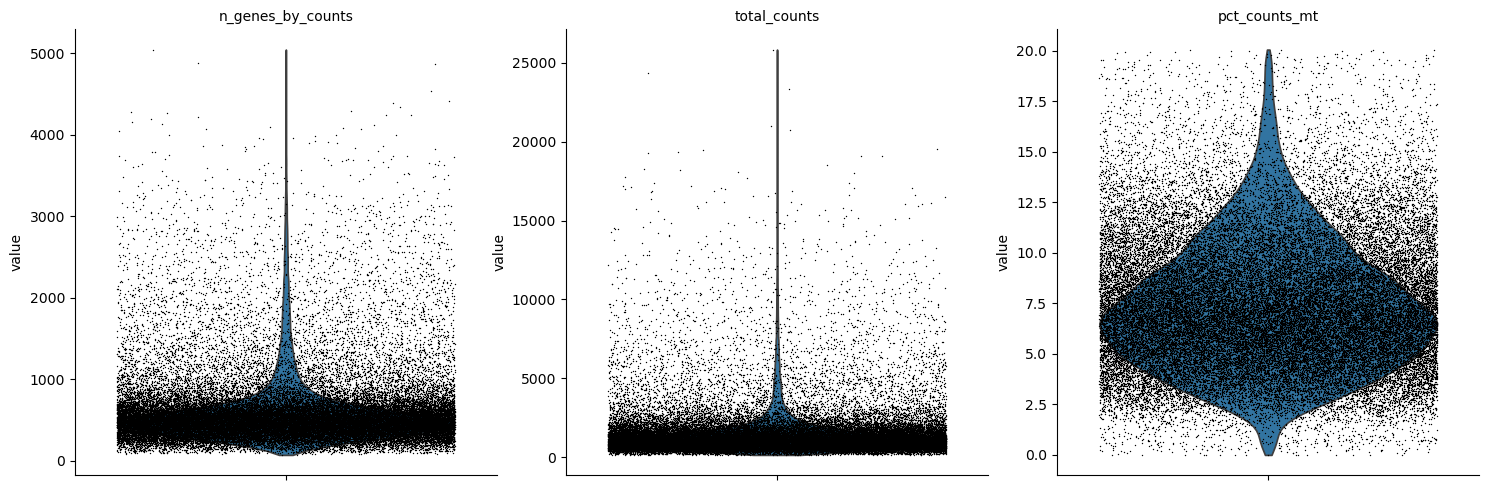

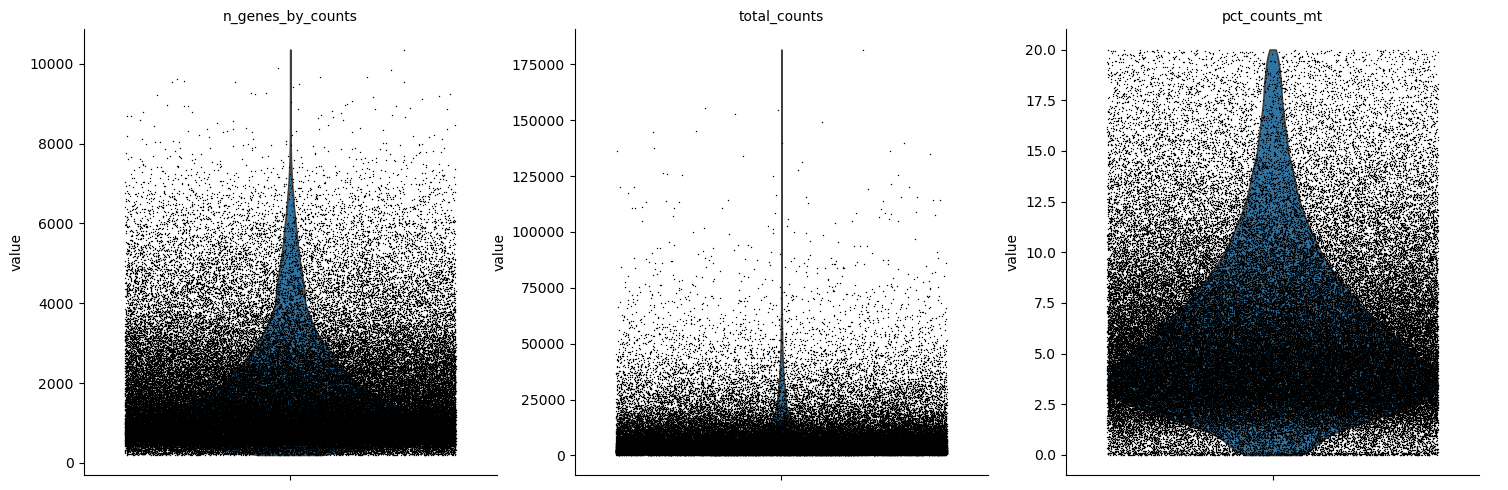

In [5]:
# Before QC plots - Dataset 1
sc.pl.violin(
    adata1,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

# Before QC plots - Dataset 2
sc.pl.violin(
    adata2,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

In [10]:
adata1_qc = adata1[
    (adata1.obs["n_genes_by_counts"] > 300) &
    (adata1.obs["n_genes_by_counts"] < 5000) &
    (adata1.obs["pct_counts_mt"] < 10)
].copy()

adata2_qc = adata2[
    (adata2.obs["n_genes_by_counts"] > 300) &
    (adata2.obs["n_genes_by_counts"] < 8000) &
    (adata2.obs["pct_counts_mt"] < 10)
].copy()

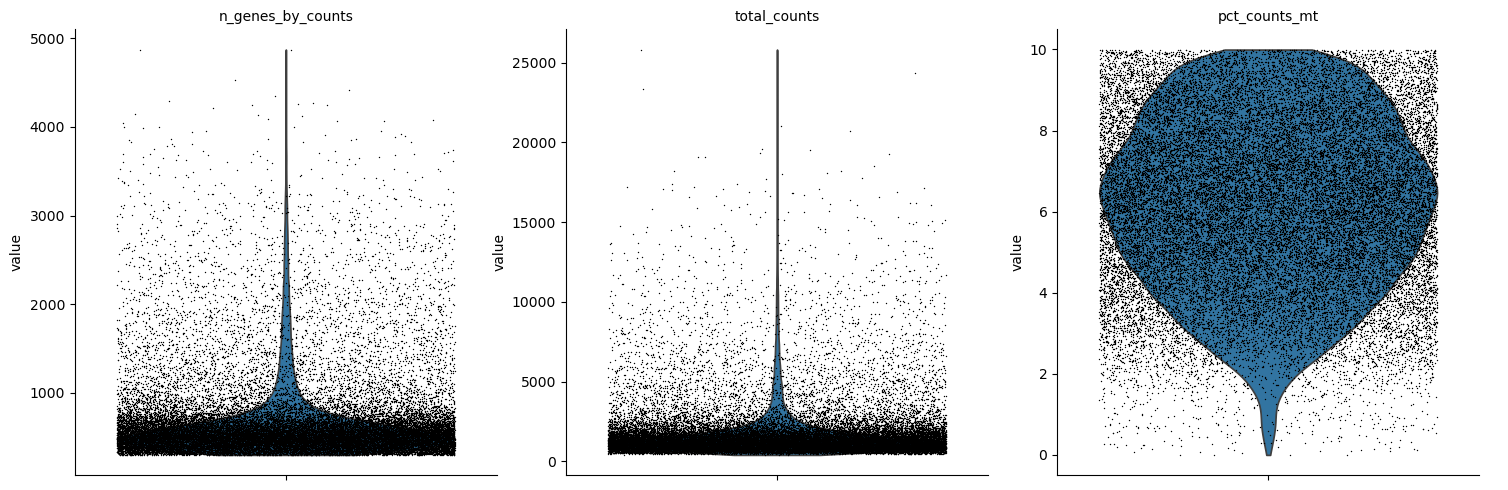

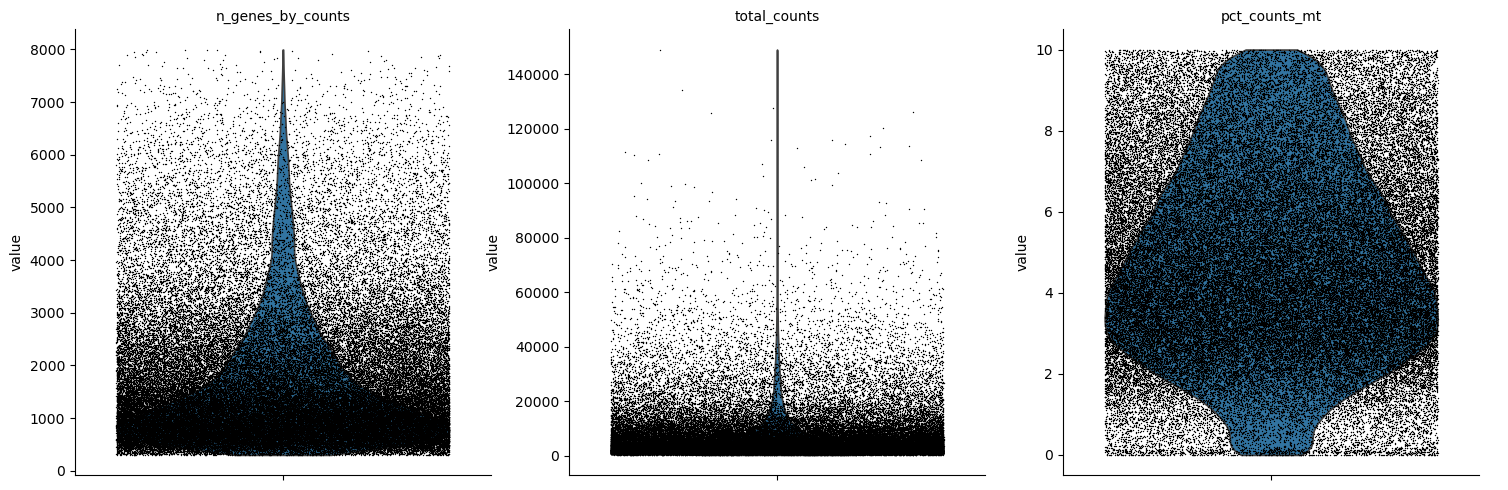

In [11]:
# After QC plots - Dataset 1
sc.pl.violin(
    adata1_qc,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

# After QC plots - Dataset 2
sc.pl.violin(
    adata2_qc,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

In [12]:
for adata in [adata1_qc, adata2_qc]:

    # Normalize counts
    sc.pp.normalize_total(adata, target_sum=1e4)

    # Log transform
    sc.pp.log1p(adata)

    # Identify highly variable genes
    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=2000
    )

print(adata1_qc.var["highly_variable"].value_counts())
print(adata2_qc.var["highly_variable"].value_counts())

highly_variable
False    12875
True      2000
Name: count, dtype: int64
highly_variable
False    27733
True      2000
Name: count, dtype: int64


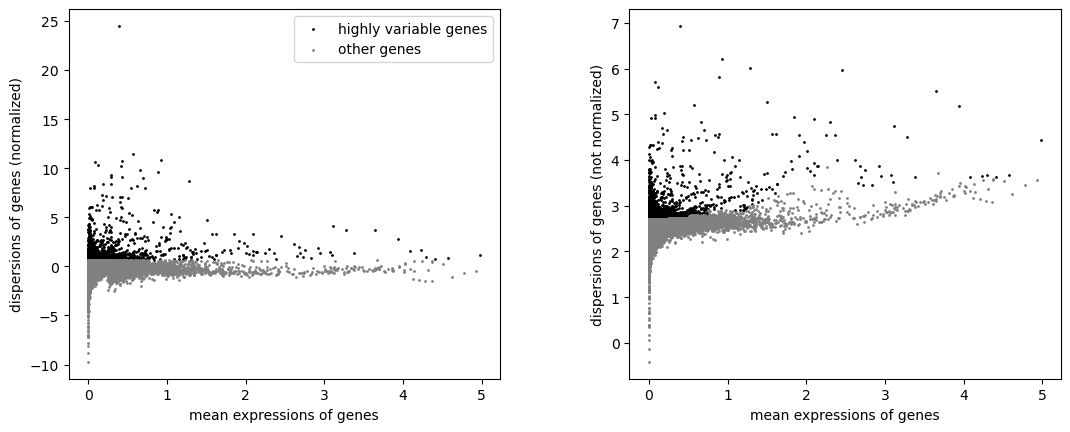

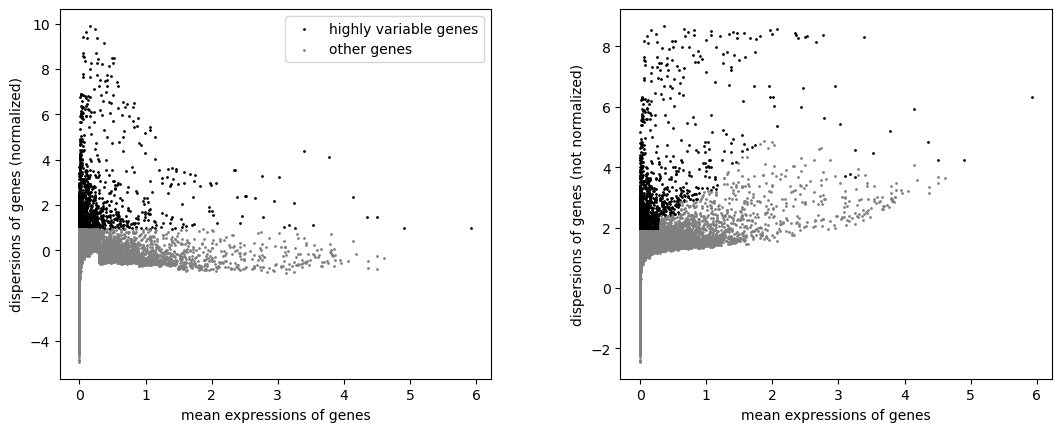

In [14]:
sc.pl.highly_variable_genes(adata1_qc)
sc.pl.highly_variable_genes(adata2_qc)

In [15]:
adata1_qc.write("GSE114725_qc.h5ad")
adata2_qc.write("GSE176078_qc.h5ad")